1. Import thư viện, đọc cars.csv, kiểm tra dữ liệu

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor

#Đọc dataset
data_path = "../data/cars.csv"
cars = pd.read_csv(data_path)
print("Kích thước dataset:", cars.shape)
cars.head()

#Kiểm tra dữ liệu
print(cars.columns.tolist())

Kích thước dataset: (12386, 11)
['brand', 'model', 'model_year', 'mileage_km', 'fuel_type', 'transmission', 'engine_size', 'body_type', 'seats', 'condition', 'price_vnd']


2. Chọn 10 thuộc tính và cột price

In [2]:
features = [
    "brand",
    "model",
    "model_year",
    "mileage_km",
    "fuel_type",
    "transmission",
    "engine_size",
    "body_type",
    "seats",
    "condition"
]

target = "price_vnd"

# Kiểm tra cột bị thiếu
required_columns = features + [target]

missing_columns = [
    column for column in required_columns
    if column not in cars.columns
]

if missing_columns:
    print("Các cột không tồn tại:", missing_columns)
else:
    print("Tên cột hợp lệ.")

Tên cột hợp lệ.


3. Làm sạch dữ liệu.

In [3]:
df = cars[features + [target]].copy()

# Loại bỏ các dòng không có giá
df = df.dropna(subset=[target])

# Nếu cột giá đang là chuỗi như "$25,000" hoặc "25,000 USD"
if df[target].dtype == "object":
    df[target] = (
        df[target]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
    )

    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Giá phải lớn hơn 0
df = df[df[target] > 0]

print("Kích thước sau khi làm sạch:", df.shape)
df.head()

Kích thước sau khi làm sạch: (12386, 11)


,brand,model,model_year,mileage_km,fuel_type,transmission,engine_size,body_type,seats,condition,price_vnd
0,Mercedes-Benz,C class C200 Exclusive,2021,38000,Gasoline,Automatic,2.0,Sedan,5,Used,1118000000
1,Nissan,Terra E 2.5 AT 2WD,2019,68000,Gasoline,Automatic,2.5,SUV,7,Used,646000000
2,Mercedes-Benz,GLC 300 4Matic,2021,40000,Gasoline,Automatic,2.0,SUV,5,Used,1759000000
3,Hyundai,SantaFe 2.4L 4WD,2016,80000,Gasoline,Automatic,2.4,SUV,7,Used,664000000
4,Kia,Carnival Luxury 2.2D,2022,32000,Diesel,Automatic,2.2,Van/Minivan,8,Used,1099000000


4. Tách X và y (đầu vào và đầu ra)

In [4]:
X = df[features]
y = df[target]

print("Dữ liệu đầu vào:", X.shape)
print("Dữ liệu đầu ra:", y.shape)

Dữ liệu đầu vào: (12386, 10)
Dữ liệu đầu ra: (12386,)


5. Xử lý cột số/cột chữ.

In [5]:
# Xác định cột số và cột chữ
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Cột số:", numeric_features)
print("Cột phân loại:", categorical_features)



Cột số: ['model_year', 'mileage_km', 'engine_size', 'seats']
Cột phân loại: ['brand', 'model', 'fuel_type', 'transmission', 'body_type', 'condition']


6. Tạo mạng neuron MLPRegressor

In [6]:
# Tiền xử lý
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)


# Mô hình
neural_network = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42
)

# Chuẩn hóa
regressor = TransformedTargetRegressor(
    regressor=neural_network,
    transformer=StandardScaler()
)

# Ghép tiền xử lý và mô hình thành một pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", regressor)
])

7. Chia tập train/test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tập huấn luyện:", X_train.shape)
print("Tập kiểm tra:", X_test.shape)

Tập huấn luyện: (9908, 10)
Tập kiểm tra: (2478, 10)


8. Huấn luyện.

In [8]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


9. Đánh giá MAE, RMSE và R².

In [9]:
# MAE: trung bình mô hình dự đoán lệch bao nhiêu tiền.
# RMSE: mức sai số, nhấn mạnh các trường hợp dự đoán sai nhiều.
# R²: càng gần 1 càng tốt.
# R² < 0: mô hình hoạt động chưa tốt.
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.0f} VNĐ")
print(f"RMSE: {rmse:,.0f} VNĐ")
print(f"R²:   {r2:.4f}")

MAE:  154,747,869 VNĐ
RMSE: 356,895,982 VNĐ
R²:   0.9459


10. Vẽ biểu đồ.

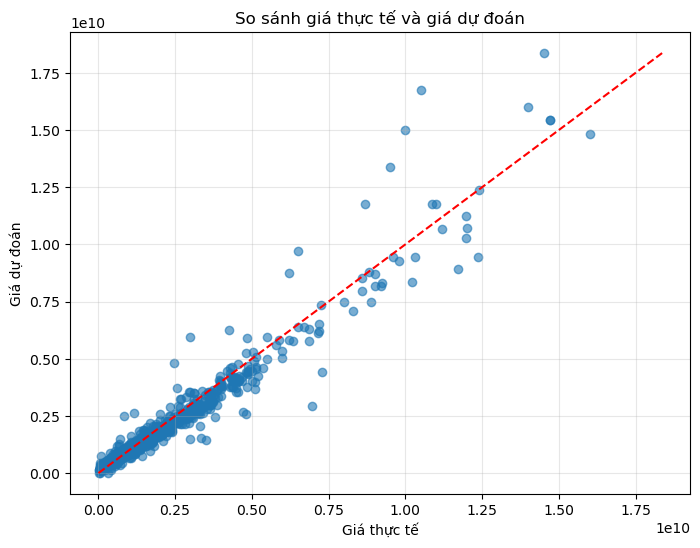

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--"
)

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế và giá dự đoán")
plt.grid(alpha=0.3)
plt.show()

11. Lưu model

In [11]:
model_path = "../models/car_price_model.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump(model, model_path)

print("Đã lưu mô hình tại:", model_path)

# Kiểm tra tải lại
model_path = "../models/car_price_model.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump(model, model_path)

print("Đã lưu mô hình tại:", model_path)

Đã lưu mô hình tại: ../models/car_price_model.pkl
Đã lưu mô hình tại: ../models/car_price_model.pkl


12. Dự đoán một chiếc xe

In [12]:
import pandas as pd
import joblib

loaded_model = joblib.load("../models/car_price_model.pkl")

new_car = pd.DataFrame([{
    "brand": "Mercedes-Benz",
    "model": "GLC 300",
    "model_year": 2017,
    "mileage_km": 50000,
    "fuel_type": "Gasoline",
    "transmission": "Automatic",
    "engine_size": 2.0,
    "body_type": "SUV",
    "seats": 5,
    "condition": "Used"
}])

new_car = new_car[features]

predicted_price = loaded_model.predict(new_car)[0]

print(f"Giá Mercedes dự đoán: {predicted_price:,.0f} VNĐ")

Giá Mercedes dự đoán: 1,260,735,852 VNĐ


In [13]:
cars[
    cars["model"].astype(str).str.contains(
        "GLC 300",
        case=False,
        na=False
    )
][features + ["price_vnd"]].head(10)


,brand,model,model_year,mileage_km,fuel_type,transmission,engine_size,body_type,seats,condition,price_vnd
2,Mercedes-Benz,GLC 300 4Matic,2021,40000,Gasoline,Automatic,2.0,SUV,5,Used,1759000000
18,Mercedes-Benz,GLC 300 4Matic,2017,50000,Gasoline,Automatic,2.0,SUV,5,Used,1068000000
19,Mercedes-Benz,GLC 300 4Matic,2024,0,Gasoline,Automatic,2.0,SUV,5,New,2600000000
44,Mercedes-Benz,GLC 300 4Matic,2021,42000,Gasoline,Automatic,2.0,SUV,5,Used,1839000000
80,Mercedes-Benz,GLC 300 4Matic,2021,43000,Gasoline,Automatic,2.0,SUV,5,Used,1799000000
105,Mercedes-Benz,GLC 300 4Matic,2021,57000,Gasoline,Automatic,2.0,SUV,5,Used,1850000000
215,Mercedes-Benz,GLC 300 4Matic,2016,0,Gasoline,Automatic,2.0,SUV,5,Used,915000000
325,Mercedes-Benz,GLC 300 4Matic,2021,17000,Gasoline,Automatic,2.0,SUV,5,Used,1879000000
432,Mercedes-Benz,GLC 300 4Matic,2018,80000,Gasoline,Automatic,2.0,SUV,5,Used,1155000000
433,Mercedes-Benz,GLC 300 4Matic,2018,87000,Gasoline,Automatic,2.0,SUV,5,Used,1040000000


In [14]:
rows = cars[
    cars["model"].astype(str).str.contains(
        "GLC 300",
        case=False,
        na=False
    )
]

rows[features + ["price_vnd"]].head(10)
sample_car = rows.iloc[[0]]

actual_price = sample_car["price_vnd"].iloc[0]
input_data = sample_car[features]

predicted_price = loaded_model.predict(input_data)[0]

print(f"Giá thực tế: {actual_price:,.0f} VNĐ")
print(f"Giá dự đoán: {predicted_price:,.0f} VNĐ")
print(f"Sai lệch: {abs(actual_price - predicted_price):,.0f} VNĐ")
print(
    f"Sai số: "
    f"{abs(actual_price - predicted_price) / actual_price * 100:.2f}%"
)

Giá thực tế: 1,759,000,000 VNĐ
Giá dự đoán: 1,607,127,311 VNĐ
Sai lệch: 151,872,689 VNĐ
Sai số: 8.63%


## 13. So sánh Linear Regression, Random Forest và MLPRegressor

Ba mô hình bên dưới sử dụng **cùng preprocessing**, **cùng tập huấn luyện** và
**cùng tập kiểm thử** đã được tạo ở trên (`random_state=42`, `test_size=0.2`).
Các chỉ số so sánh gồm:

- **MAE**: sai số tuyệt đối trung bình, càng thấp càng tốt.
- **RMSE**: căn bậc hai sai số bình phương trung bình, càng thấp càng tốt.
- **R²**: tỷ lệ biến thiên được mô hình giải thích, càng gần 1 càng tốt.


In [15]:
from time import perf_counter

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Mỗi mô hình có một bản sao preprocessing riêng để tránh chia sẻ fitted state.
estimators = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "MLPRegressor": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        random_state=42,
    ),
}

comparison_rows = []
comparison_models = {}
comparison_predictions = {}

for model_name, estimator in estimators.items():
    started_at = perf_counter()

    # Chuẩn hóa target giúp MLP hội tụ ổn định; phép biến đổi được áp dụng
    # giống nhau cho cả ba mô hình để bảo đảm quy trình so sánh nhất quán.
    regressor = TransformedTargetRegressor(
        regressor=estimator,
        transformer=StandardScaler(),
    )
    comparison_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("regressor", regressor),
    ])

    comparison_pipeline.fit(X_train, y_train)
    y_pred = comparison_pipeline.predict(X_test)

    comparison_models[model_name] = comparison_pipeline
    comparison_predictions[model_name] = y_pred
    comparison_rows.append({
        "Model": model_name,
        "MAE (VNĐ)": mean_absolute_error(y_test, y_pred),
        "RMSE (VNĐ)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred),
        "Thời gian train (giây)": perf_counter() - started_at,
    })

comparison_results = (
    pd.DataFrame(comparison_rows)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

# Bảng dễ đọc theo đơn vị triệu VNĐ; comparison_results vẫn giữ số liệu gốc.
comparison_display = comparison_results.copy()
comparison_display["MAE (triệu VNĐ)"] = comparison_display.pop("MAE (VNĐ)") / 1_000_000
comparison_display["RMSE (triệu VNĐ)"] = comparison_display.pop("RMSE (VNĐ)") / 1_000_000

comparison_display.style.format({
    "MAE (triệu VNĐ)": "{:.2f}",
    "RMSE (triệu VNĐ)": "{:.2f}",
    "R²": "{:.4f}",
    "Thời gian train (giây)": "{:.2f}",
}).highlight_min(
    subset=["MAE (triệu VNĐ)", "RMSE (triệu VNĐ)"],
    color="#d1fae5",
).highlight_max(
    subset=["R²"],
    color="#d1fae5",
)


,Model,R²,Thời gian train (giây),MAE (triệu VNĐ),RMSE (triệu VNĐ)
0,Random Forest,0.9609,32.13,87.41,303.46
1,MLPRegressor,0.9459,14.31,154.75,356.90
2,Linear Regression,0.8024,2.01,214.36,682.23


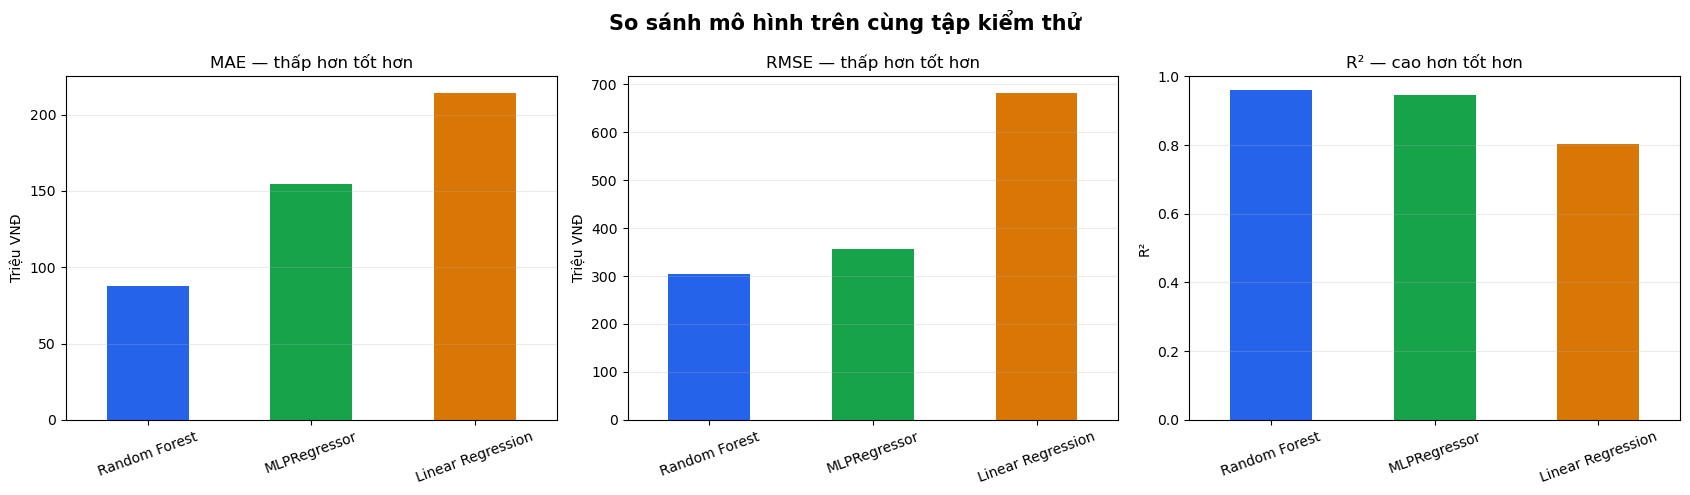

Mô hình có R² tốt nhất: Random Forest


In [16]:
import matplotlib.pyplot as plt


plot_data = comparison_display.set_index("Model")
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

plot_data["MAE (triệu VNĐ)"].plot(
    kind="bar", ax=axes[0], color=["#2563eb", "#16a34a", "#d97706"]
)
axes[0].set_title("MAE — thấp hơn tốt hơn")
axes[0].set_ylabel("Triệu VNĐ")

plot_data["RMSE (triệu VNĐ)"].plot(
    kind="bar", ax=axes[1], color=["#2563eb", "#16a34a", "#d97706"]
)
axes[1].set_title("RMSE — thấp hơn tốt hơn")
axes[1].set_ylabel("Triệu VNĐ")

plot_data["R²"].plot(
    kind="bar", ax=axes[2], color=["#2563eb", "#16a34a", "#d97706"]
)
axes[2].set_title("R² — cao hơn tốt hơn")
axes[2].set_ylabel("R²")
axes[2].set_ylim(min(0, plot_data["R²"].min() - 0.05), 1.0)

for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.25)

plt.suptitle("So sánh mô hình trên cùng tập kiểm thử", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

best_model_name = comparison_results.iloc[0]["Model"]
print(f"Mô hình có R² tốt nhất: {best_model_name}")
